# Sydney Housing Price Prediction and Decision Support System

**Mini Project - Machine Learning (Distinction Task)**

This notebook implements the full machine learning lifecycle for predicting residential
property sale prices across three contrasting Sydney suburbs: **Randwick** (premium),
**Parramatta** (middle-ring, unit-heavy), and **Campbelltown** (affordable, house-dominant).

## Contents
1. Environment Setup
2. Data Loading and Initial Inspection
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Development (Ridge/Lasso, KNN Regressor, Decision Tree Regressor)
6. Model Evaluation and Cross-Validation
7. Investigating Prediction Failures
8. Human vs. ML vs. LLM Comparison
9. Deployment

## 1. Environment Setup

Before working with any data, we import the Python libraries this project depends on.
Each one has a specific job:

- **pandas** - loads and manipulates our tabular data (rows = properties, columns = features).
  This is the backbone of nearly every step: reading the Excel file, cleaning it,
  computing statistics, engineering new features.
- **numpy** - provides fast numerical operations (arrays, math functions) that pandas
  and scikit-learn are built on top of.
- **matplotlib** and **seaborn** - visualisation libraries. matplotlib is the low-level
  plotting engine; seaborn sits on top of it and makes statistical plots (boxplots,
  distributions, correlation heatmaps) much easier to produce, as seen in our Week 5/6
  practicals.
- **scikit-learn (sklearn)** - the machine learning library providing our models
  (Ridge, Lasso, KNeighborsRegressor, DecisionTreeRegressor), data splitting tools
  (train_test_split, KFold), and evaluation metrics (MSE, RMSE, MAE, R²).

We import these once, at the top of the notebook, following standard data science
convention - every later cell can then use them without re-importing.

In [1]:
import importlib
import subprocess
import sys

# Map: import name -> pip install name (sometimes these differ, e.g. sklearn -> scikit-learn)
required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "openpyxl": "openpyxl",  # needed by pandas to read .xlsx files
}

for import_name, pip_name in required_packages.items():
    try:
        importlib.import_module(import_name)
        print(f"[OK]      {import_name} is already installed.")
    except ImportError:
        print(f"[MISSING] {import_name} not found — installing {pip_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
        print(f"[DONE]    {pip_name} installed.")

print("\nEnvironment check complete.")

[OK]      pandas is already installed.
[OK]      numpy is already installed.
[OK]      matplotlib is already installed.
[OK]      seaborn is already installed.
[OK]      sklearn is already installed.
[OK]      openpyxl is already installed.

Environment check complete.


In [2]:
# Core data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning: data splitting, tuning, and evaluation
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Machine learning: our three regression models
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Display settings — show more rows/columns when previewing data
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Consistent visual style for all plots in this notebook
sns.set_style('whitegrid')

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Data Loading and Initial Inspection

In this section, I load the housing dataset I manually collected from realestate.com.au
and domain.com.au, covering 102 sold properties across three Sydney suburbs: Randwick,
Parramatta, and Campbelltown.

Before doing any analysis or modelling, I first inspect the raw data to confirm it has
loaded correctly, check its structure (number of rows/columns, data types), and get an
initial sense of data quality (missing values, obvious errors). This step matters because
every later step — visualisation, feature engineering, and model training depends on
starting from a correctly loaded, well-understood dataset.

In [3]:
# Load the housing dataset from the Excel file
# Note: this notebook and the Excel file must be in the same folder for this path to work
df = pd.read_excel("Sydney_Housing_Data_Collection.xlsx", sheet_name="Data")

# Display the first 5 rows to confirm the data has loaded correctly
df.head()

,property_id,suburb,address,sale_date,property_type,bedrooms,bathrooms,car_spaces,size_sqm,distance_to_cbd_km,listing_url,sale_price
0,P001,Parramatta,"89/459-463 Church Street, Parramatta NSW 2150",2026-04-09,Unit,2,2,1.0,136.0,25.5,https://www.domain.com.au/89-459-463-church-st...,580000
1,P002,Parramatta,"22/4 Peace Lane, Parramatta NSW 2150",2026-09-19,Unit,2,2,1.0,101.0,26.6,https://www.domain.com.au/22-4-peace-lane-parr...,500000
2,P003,Parramatta,"4/44-50 Thomas Street, Parramatta NSW 2150",2026-09-16,Townhouse,2,1,1.0,128.0,24.0,https://www.domain.com.au/4-44-50-thomas-stree...,720000
3,P004,Parramatta,"2315/45 Macquarie Street, Parramatta NSW 2150",2026-09-16,Unit,2,2,1.0,97.0,26.2,https://www.domain.com.au/2315-45-macquarie-st...,640000
4,P005,Parramatta,"610/36-46 Cowper Street, Parramatta NSW 2150",2026-09-14,Unit,2,2,1.0,113.0,24.2,https://www.domain.com.au/610-36-46-cowper-str...,575000


### 2.1 Checking Data Structure and Types

Having confirmed the data loads correctly, I now check:

- The overall shape of the dataset (number of rows and columns)
- The data type pandas has assigned to each column (numeric, text, date)
- Which columns contain missing values, and how many

This is important because a column with the wrong data type can silently break later
steps. For example, if `sale_price` were accidentally read as text rather than a number,
I would not be able to calculate an average price or train a regression model on it.

In [4]:
# Check the number of rows and columns in the dataset
print("Dataset shape (rows, columns):", df.shape)
print()

# Check the data type of each column, and count of non-null values
# This helps me spot any column that has been read with the wrong type
df.info()

Dataset shape (rows, columns): (102, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   property_id         102 non-null    object        
 1   suburb              102 non-null    object        
 2   address             102 non-null    object        
 3   sale_date           102 non-null    datetime64[ns]
 4   property_type       102 non-null    object        
 5   bedrooms            102 non-null    int64         
 6   bathrooms           102 non-null    int64         
 7   car_spaces          91 non-null     float64       
 8   size_sqm            91 non-null     float64       
 9   distance_to_cbd_km  102 non-null    float64       
 10  listing_url         102 non-null    object        
 11  sale_price          102 non-null    int64         
dtypes: datetime64[ns](1), float64(3), int64(3), object(5)
memory usa

### 2.2 Note on Data Collection: Property Size Measurement

During initial inspection, I found that my originally-collected `land_size_sqm` column
was entirely empty, while `building_size_sqm` was populated for most properties. On
reflection, I recognised that during data collection I recorded whichever size figure
was most prominently displayed on each listing, without consistently distinguishing
between land size and internal floor area. For units this is almost always floor area;
for houses, listings often foreground land size instead.

To reflect this honestly, I relabelled this column as a general `size_sqm` feature
rather than asserting it consistently represents either land size or building size.
I acknowledge this as a data quality limitation: the feature may not be perfectly
comparable across property types, and this is discussed further in the data quality
and limitations section of this report.

In [5]:
# I check how missing values in size_sqm and car_spaces are distributed across
# property types and suburbs. This tells me WHERE the gaps are concentrated,
# which will inform how I handle these gaps later (e.g. imputation strategy)
# and gives me concrete evidence for the data quality discussion in my report.

print("Missing size_sqm count, by property_type:")
print(df[df["size_sqm"].isna()]["property_type"].value_counts())

print("\nMissing car_spaces count, by property_type:")
print(df[df["car_spaces"].isna()]["property_type"].value_counts())

print("\nMissing size_sqm count, by suburb:")
print(df[df["size_sqm"].isna()]["suburb"].value_counts())

print("\nMissing car_spaces count, by suburb:")
print(df[df["car_spaces"].isna()]["suburb"].value_counts())

Missing size_sqm count, by property_type:
property_type
Unit    11
Name: count, dtype: int64

Missing car_spaces count, by property_type:
property_type
House    7
Unit     4
Name: count, dtype: int64

Missing size_sqm count, by suburb:
suburb
Parramatta    8
Randwick      3
Name: count, dtype: int64

Missing car_spaces count, by suburb:
suburb
Randwick        7
Campbelltown    4
Name: count, dtype: int64


### 2.3 Missing Data Pattern Analysis

Examining the missingness pattern reveals that gaps are not randomly distributed
across the dataset, but are concentrated in specific suburb/property-type
combinations:

- **`size_sqm`** is missing for 11 properties, all of which are Units. 8 in
  Parramatta and 3 in Randwick. No missing values occur in Campbelltown, which is
  consistent with Campbelltown being house-dominant in this dataset (houses more
  reliably report a size figure on their listings).
- **`car_spaces`** is missing for 11 properties (7 Houses, 4 Units) concentrated
  in Randwick (7) and Campbelltown (4), with zero missing in Parramatta.

This pattern suggests the missingness is **not completely random** (MCAR), but
related to suburb and property type. This is an important consideration for how
I handle these gaps in feature engineering, and is discussed further in the
data quality and limitations section of this report.

### 2.4 Summary Statistics

Before visualising the data, I generate summary statistics for all numeric columns.
This gives me the range, average, and spread of each feature, and is a useful way
to catch potential data entry errors (e.g. an unrealistically low or high value)
before they influence any later analysis.

In [6]:
# Generate summary statistics (count, mean, std, min, quartiles, max) for all
# numeric columns. I use this to sanity-check value ranges before visualising
# or modelling the data — e.g. checking that sale_price and bedrooms fall
# within plausible real-world bounds.
df.describe()

,sale_date,bedrooms,bathrooms,car_spaces,size_sqm,distance_to_cbd_km,sale_price
count,102,102.000000,102.000000,91.000000,91.000000,102.000000,1.020000e+02
mean,2026-06-03 23:45:52.941176576,2.882353,1.754902,1.329670,311.850549,27.926471,1.487873e+06
min,2026-01-03 00:00:00,1.000000,1.000000,0.000000,46.500000,6.500000,3.200000e+05
25%,2026-04-08 06:00:00,2.000000,1.000000,1.000000,112.000000,7.500000,7.225000e+05
50%,2026-06-15 12:00:00,2.000000,2.000000,1.000000,192.000000,24.000000,9.607500e+05
75%,2026-07-23 18:00:00,3.000000,2.000000,1.500000,555.000000,53.750000,1.497500e+06
max,2026-09-19 00:00:00,12.000000,6.000000,6.000000,903.400000,61.000000,6.100000e+06
std,NaN,1.612415,0.894829,0.803533,234.147252,19.893185,1.302627e+06


### 2.5 Investigating Outliers Flagged by Summary Statistics

The summary statistics reveal a maximum of 12 bedrooms, which is unusually high for
standard residential property and warrants investigation before proceeding. This
could reflect a genuine large or multi-dwelling property, or a data entry error.

I also check that `distance_to_cbd_km` is consistent within each suburb, since I
intentionally assigned a single fixed distance value per suburb during data
collection (based on road distance from Sydney GPO) rather than measuring each
property individually.

In [7]:
# Investigate the property (or properties) with an unusually high bedroom count
print("Properties with 6 or more bedrooms:")
print(df[df["bedrooms"] >= 6][["property_id", "suburb", "address", "property_type",
                                  "bedrooms", "bathrooms", "sale_price", "listing_url"]])

print("\n" + "="*80)

# Check that distance_to_cbd_km is consistent within each suburb, as intended
print("\ndistance_to_cbd_km summary, grouped by suburb:")
print(df.groupby("suburb")["distance_to_cbd_km"].describe())

Properties with 6 or more bedrooms:
   property_id        suburb                                      address  \
21        P022    Parramatta     37A Sutherland Road, Parramatta NSW 2150   
67        R035      Randwick           224 Alison Road, Randwick NSW 2031   
80        C011  Campbelltown  198 Broughton Street, Campbelltown NSW 2560   
93        C024  Campbelltown       6 Hoddle Avenue, Campbelltown NSW 2560   

   property_type  bedrooms  bathrooms  sale_price  \
21          Unit        12          6     3425000   
67         House         9          5     5300000   
80         House         6          2     1160555   
93         House         7          3     1200000   

                                          listing_url  
21  https://www.domain.com.au/37a-sutherland-road-...  
67  https://www.domain.com.au/224-alison-road-rand...  
80  https://www.domain.com.au/198-broughton-street...  
93  https://www.domain.com.au/6-hoddle-avenue-camp...  


distance_to_cbd_km summary, gr

### 2.7 Excluding a Non-Comparable Property

On investigation, property `P022` (37A Sutherland Road, Parramatta) was found to be
listed as a **"Block of Units"** rather than a single residential dwelling — its
listing describes 12 bedrooms and 6 bathrooms across 903.4m², reflecting multiple
combined dwellings sold as one investment transaction. This is not comparable to the
single-dwelling residential sales that make up the rest of the dataset, as its price
reflects the value of several separate properties rather than one home.

I therefore exclude this property from the dataset, reducing the working sample from
102 to 101 properties.

In [8]:
# Remove property P022, identified as a "Block of Units" (a multi-dwelling
# investment sale) rather than a single residential property. Including it would
# distort price-per-bedroom and price-per-sqm relationships, since its price
# reflects multiple combined dwellings rather than one home.
df = df[df["property_id"] != "P022"].reset_index(drop=True)

# Confirm the row count after exclusion
print("Dataset shape after excluding P022:", df.shape)
print("\nSuburb counts after exclusion:")
print(df["suburb"].value_counts())

Dataset shape after excluding P022: (101, 12)

Suburb counts after exclusion:
suburb
Randwick        37
Parramatta      32
Campbelltown    32
Name: count, dtype: int64


## 3. Exploratory Data Analysis

With a clean dataset of 101 properties, I now explore the data in depth before any
feature engineering or modelling. This section addresses the requirements of Part 2:
understanding the distribution of housing prices, investigating differences between
suburbs, examining trends over time, and identifying outliers.

I begin with the distribution of `sale_price`, since this is my target variable
understanding its shape (e.g. whether it is skewed) is essential before choosing how
to model it.

### 3.1 Distribution of Sale Price

Housing prices are well known to be **right-skewed**: most properties cluster in a
low-to-moderate price range, with a smaller number of very expensive properties
forming a long tail toward higher values. This matters for two reasons:

1. It affects which summary statistics are meaningful - the mean can be pulled
   upward by a small number of very expensive properties, so the median is often
   a more representative "typical price."
2. It affects modelling choices later on - a heavily skewed target variable can
   sometimes benefit from a log transformation before fitting a linear model like
   Ridge or Lasso Regression, since linear models assume a roughly linear
   relationship between features and the target.

I visualise the distribution using a histogram to check whether this expected
skew is present in my own dataset.

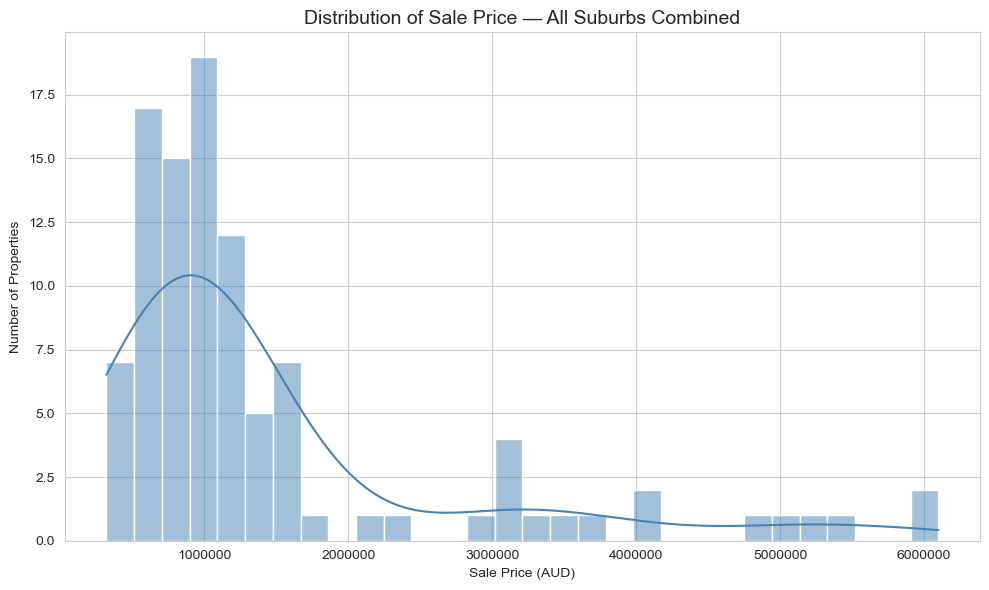

Mean sale price:   $1,468,694
Median sale price: $951,000
Skewness:          2.09


In [9]:
# Plot the distribution of sale_price across the whole dataset (all 3 suburbs combined)
# A histogram shows how many properties fall into each price range, letting me see
# the overall shape of the distribution (e.g. symmetric vs skewed).
plt.figure(figsize=(10, 6))
sns.histplot(df["sale_price"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Sale Price — All Suburbs Combined", fontsize=14)
plt.xlabel("Sale Price (AUD)")
plt.ylabel("Number of Properties")
plt.ticklabel_format(style="plain", axis="x")  # avoid scientific notation on x-axis
plt.tight_layout()
plt.show()

# Print the mean and median to quantify the skew numerically
print(f"Mean sale price:   ${df['sale_price'].mean():,.0f}")
print(f"Median sale price: ${df['sale_price'].median():,.0f}")
print(f"Skewness:          {df['sale_price'].skew():.2f}")

**Interpretation:** The distribution of sale price is strongly right-skewed
(skewness = 2.09). The mean (1,468,694) is substantially higher than the median
(951,000), indicating that a relatively small number of high-value properties,
most likely concentrated in Randwick are pulling the average upward. The majority
of properties in the dataset cluster between approximately 500,000 and 1,500,000,
with a long, sparse tail extending toward 6,000,000.

This skew has a practical implication for modelling: linear models such as Ridge and
Lasso Regression assume an approximately linear relationship between features and
the target variable. A log transformation of `sale_price` may therefore be considered
during model development (Part 3) to reduce the influence of extreme high-value
properties and improve the linearity of this relationship.

### 3.2 Sale Price by Suburb

Having established that overall sale price is right-skewed, I now examine whether
this pattern differs by suburb. Since Randwick, Parramatta, and Campbelltown were
deliberately selected to represent different price tiers, I expect to see a clear
separation between suburbs, with Randwick showing both a higher median price and
greater spread (reflecting the wide range of premium property types it contains).

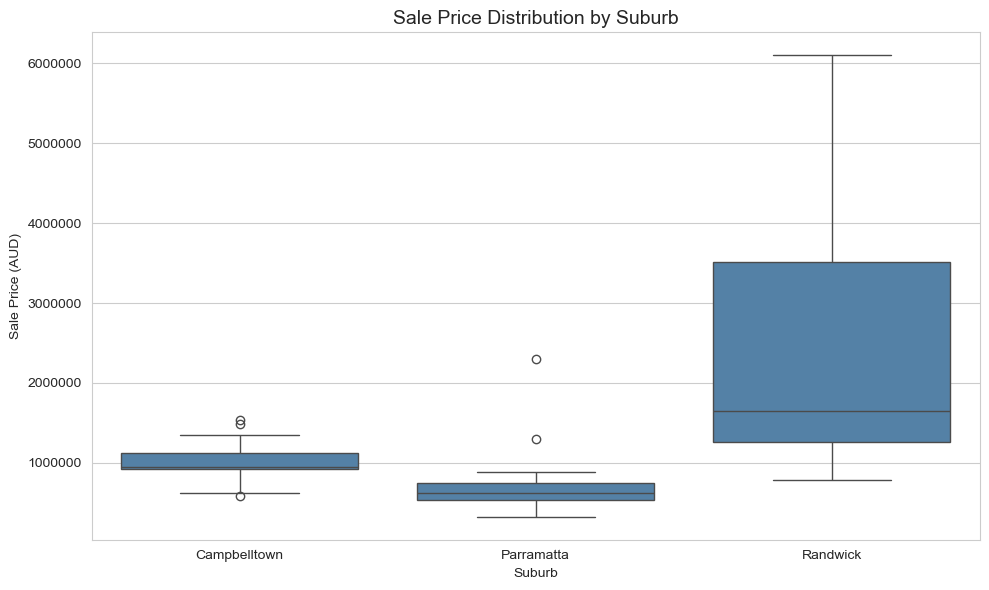

Median sale price by suburb:
suburb
Parramatta       620000.0
Campbelltown     950500.0
Randwick        1650000.0
Name: sale_price, dtype: float64


In [10]:
# Compare sale price distributions across the 3 suburbs using a boxplot.
# A boxplot shows the median, interquartile range (the "typical" middle 50% of
# prices), and outliers for each suburb side by side, making it easy to compare
# both the typical price level and the spread within each suburb.
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="suburb", y="sale_price",
            order=["Campbelltown", "Parramatta", "Randwick"],  # ordered low to high price tier
            color="steelblue")
plt.title("Sale Price Distribution by Suburb", fontsize=14)
plt.xlabel("Suburb")
plt.ylabel("Sale Price (AUD)")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

# Print median price per suburb for a precise numerical comparison
print("Median sale price by suburb:")
print(df.groupby("suburb")["sale_price"].median().sort_values())

### 3.3 An Unexpected Finding: Suburb Price Ordering

The boxplot reveals a result that does not match my initial expectation. I anticipated
a clean price gradient of Campbelltown < Parramatta < Randwick, reflecting the
"affordable / middle / premium" framing used when selecting these suburbs. Instead,
the actual median prices are:

- Parramatta: 620,000
- Campbelltown: 950,500
- Randwick: 1,650,000

Campbelltown's median price is notably **higher** than Parramatta's, reversing the
expected middle-tier ordering. Randwick remains clearly the most expensive suburb,
confirming the premium end of my original expectation.

A likely explanation is that suburb price alone is confounded with property type:
Parramatta is a unit-heavy suburb, while Campbelltown is house-dominant. A standalone
house, even in a relatively affordable outer suburb, may sell for more than a small
apartment in a comparatively pricier inner-city hub. I test this explanation directly
in the next step by examining the property type mix within each suburb.

In [11]:
# I test whether property type composition explains the unexpected suburb price
# ordering, by checking the proportion of each property type within each suburb,
# and comparing median price by suburb AND property type together.

print("Property type counts by suburb:")
print(pd.crosstab(df["suburb"], df["property_type"]))

print("\nMedian sale price by suburb AND property type:")
print(df.groupby(["suburb", "property_type"])["sale_price"].median())

Property type counts by suburb:
property_type  House  Townhouse  Unit
suburb                               
Campbelltown      29          2     1
Parramatta         1          2    29
Randwick          15          0    22

Median sale price by suburb AND property type:
suburb        property_type
Campbelltown  House             970500.0
              Townhouse         810000.0
              Unit              587000.0
Parramatta    House            2300000.0
              Townhouse        1010000.0
              Unit              580000.0
Randwick      House            4000000.0
              Unit             1283000.0
Name: sale_price, dtype: float64


### 3.4 Confirming the Property Type Explanation

Comparing median prices within property type confirms that property type composition
explains the earlier unexpected suburb ordering:

- **Units**: Campbelltown (587,000) and Parramatta (580,000) are nearly identical,
  with Randwick clearly highest (1,283,000) consistent with my original
  price-tier expectation.
- **Houses**: Campbelltown (970,500) is well below Randwick (4,000,000), again
  consistent with expectations. Parramatta's house median (2,300,000) cannot be
  reliably interpreted, as it is based on only 1 house sale in this dataset, a
  reflection of Parramatta's unit-dominant listing pool rather than a meaningful
  suburb estimate.

This confirms that the raw suburb-level price ordering observed earlier was driven
substantially by differing property type composition across suburbs (Parramatta
being unit-dominant, Campbelltown house-dominant), rather than contradicting my
original expectation about suburb price tiers. This is an important finding: it
indicates that `property_type` and `suburb` are likely to interact in any model of
price, and both should be included as features rather than relying on suburb alone.

### 3.5 Sale Price Trends Over Time

Since my dataset spans sales from approximately January 2026 to September 2026, I
now examine whether sale price shows any trend across this period. This matters for
two reasons: first, the brief specifically asks me to examine trends over time;
second, if prices moved meaningfully within my collection window, this is useful
context for interpreting my model later, a model trained on this window reflects
market conditions specific to this period, not a timeless relationship.

I visualise this as a scatter plot of sale price against sale date, coloured by
suburb, so that any trend can be examined both overall and within each suburb.

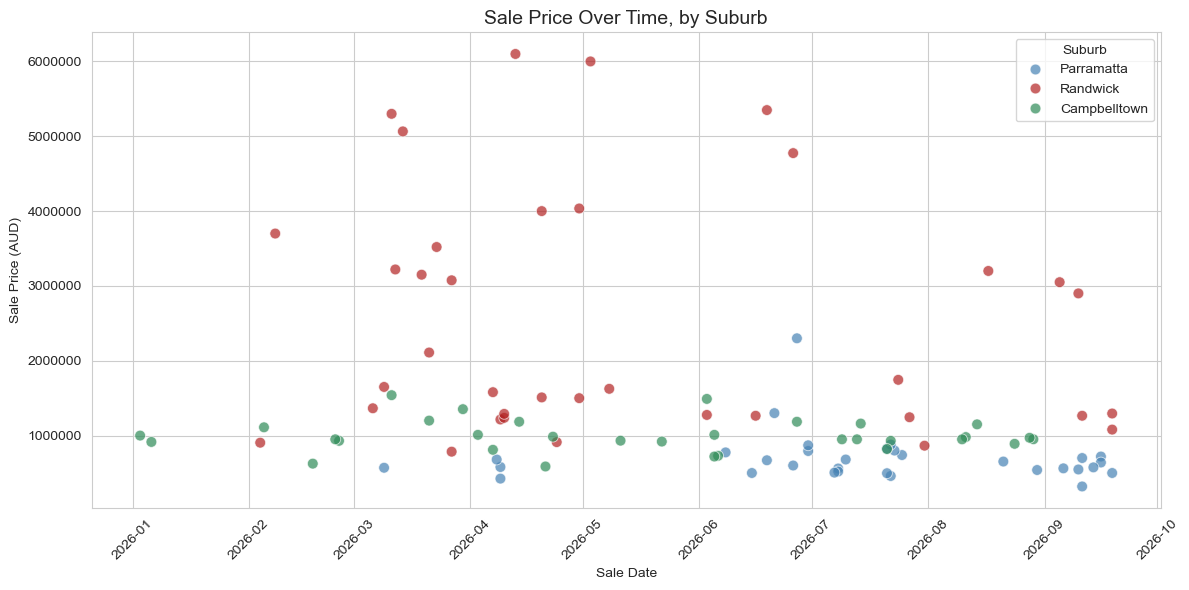

Correlation between sale date and price, by suburb:
suburb
Campbelltown   -0.060120
Parramatta     -0.092667
Randwick       -0.160696
dtype: float64


C:\Users\Thiveekshan\AppData\Local\Temp\ipykernel_62028\1631860454.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(df.groupby("suburb").apply(lambda g: g["sale_date_numeric"].corr(g["sale_price"])))


In [12]:
# Plot sale_price against sale_date, coloured by suburb, to visually check for any
# trend over the data collection window. I use scatter rather than line plot since
# sales are irregular, individual events rather than a continuous time series.
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x="sale_date", y="sale_price", hue="suburb",
                 palette={"Randwick": "firebrick", "Parramatta": "steelblue",
                          "Campbelltown": "seagreen"}, alpha=0.7, s=60)
plt.title("Sale Price Over Time, by Suburb", fontsize=14)
plt.xlabel("Sale Date")
plt.ylabel("Sale Price (AUD)")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=45)
plt.legend(title="Suburb")
plt.tight_layout()
plt.show()

# Quantify the trend numerically: correlation between sale_date (as a number)
# and sale_price, calculated separately per suburb since price LEVELS differ
# so much between suburbs that a combined correlation would be misleading.
df["sale_date_numeric"] = df["sale_date"].map(pd.Timestamp.toordinal)
print("Correlation between sale date and price, by suburb:")
print(df.groupby("suburb").apply(lambda g: g["sale_date_numeric"].corr(g["sale_price"])))

**Interpretation:** Correlations between sale date and price are weak for all three
suburbs (Campbelltown: -0.06, Parramatta: -0.09, Randwick: -0.16), indicating no
strong time trend within the roughly 8-month collection window (January–September
2026). This is broadly consistent with market context gathered during suburb
selection, where premium Sydney suburbs were reported to be softening slightly from
a late-2025 peak rather than showing strong directional movement. Since price
variation within this window is not strongly explained by time, I do not treat
`sale_date` as a major predictive feature going forward, though it remains useful
context for interpreting the dataset's temporal scope.

In [13]:
# Recalculate sale date vs price correlation per suburb using a cleaner approach
# (avoids the FutureWarning from the previous groupby().apply() method)
correlations = {}
for suburb in df["suburb"].unique():
    subset = df[df["suburb"] == suburb]
    correlations[suburb] = subset["sale_date_numeric"].corr(subset["sale_price"])

print("Correlation between sale date and price, by suburb:")
for suburb, corr in correlations.items():
    print(f"  {suburb}: {corr:.3f}")

Correlation between sale date and price, by suburb:
  Parramatta: -0.093
  Randwick: -0.161
  Campbelltown: -0.060


### 3.6 Outlier Detection

Having already removed one clear non-comparable property (P022, a "Block of Units")
during initial inspection, I now formally check for any remaining outliers using
boxplots split by suburb and property type. This is a more systematic check than
relying on summary statistics alone, and lets me visually confirm whether any
remaining extreme values are genuine (e.g. a legitimately large or luxury property)
or warrant further investigation.

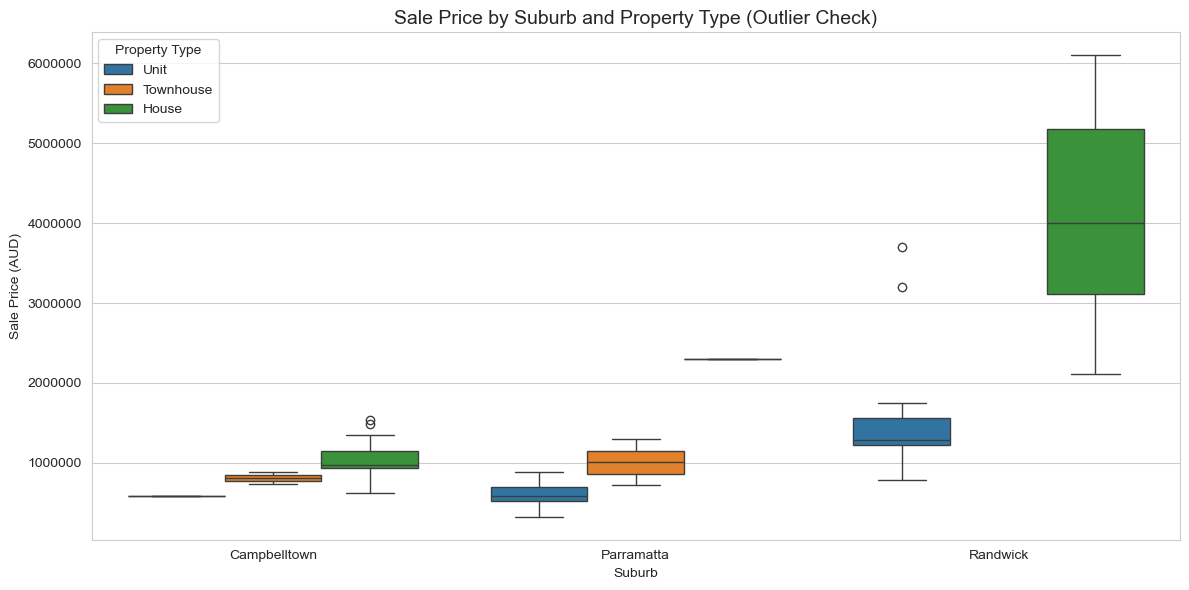

Number of outliers detected (IQR method, within suburb + property type): 4

   property_id        suburb property_type  bedrooms  bathrooms  sale_price
94        C026  Campbelltown         House         5          4     1540000
95        C027  Campbelltown         House         5          3     1490000
38        R007      Randwick          Unit         3          2     3200000
40        R009      Randwick          Unit         3          2     3700000


C:\Users\Thiveekshan\AppData\Local\Temp\ipykernel_62028\1661276272.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outliers = df.groupby(["suburb", "property_type"], group_keys=False).apply(flag_outliers)


In [14]:
# I use boxplots of sale_price, split by suburb AND property type, to visually
# identify any remaining outliers (points falling outside the whiskers).
# This is more precise than a single overall boxplot, since "normal" price ranges
# differ substantially between suburbs and property types.
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="suburb", y="sale_price", hue="property_type",
            order=["Campbelltown", "Parramatta", "Randwick"])
plt.title("Sale Price by Suburb and Property Type (Outlier Check)", fontsize=14)
plt.xlabel("Suburb")
plt.ylabel("Sale Price (AUD)")
plt.ticklabel_format(style="plain", axis="y")
plt.legend(title="Property Type")
plt.tight_layout()
plt.show()

# Formally identify outliers using the IQR (interquartile range) method,
# calculated WITHIN each suburb + property_type group, since "normal" price
# ranges differ substantially between these groups.
def flag_outliers(group):
    q1 = group["sale_price"].quantile(0.25)
    q3 = group["sale_price"].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return group[(group["sale_price"] < lower_bound) | (group["sale_price"] > upper_bound)]

# Note: I do NOT use include_groups=False here, since I need to keep the
# suburb and property_type columns in the output to identify which group
# each outlier belongs to.
outliers = df.groupby(["suburb", "property_type"], group_keys=False).apply(flag_outliers)

print(f"Number of outliers detected (IQR method, within suburb + property type): {len(outliers)}")
print()
print(outliers[["property_id", "suburb", "property_type", "bedrooms", "bathrooms", "sale_price"]]
      .sort_values(["suburb", "property_type"]))

### 3.7 Outlier Assessment and Decision

The IQR method flagged 4 outliers, calculated within each suburb + property type
group:

- **C026, C027** (Campbelltown Houses, 1.54M and 1.49M): both are large properties
  (5 bedrooms, 3–4 bathrooms), consistent with genuinely larger, higher-value homes
  rather than data errors.
- **R007, R009** (Randwick Units, 3.2M and 3.7M): both are 3-bedroom, 2-bathroom
  units, plausibly representing premium/penthouse-style apartments, which do exist
  within Sydney's harbourside and eastern suburbs unit market.

Unlike P022 (excluded earlier as a structurally non-comparable "Block of Units"
listing), these four properties are correctly categorised single-dwelling sales with
bedroom/bathroom counts that reasonably support their sale price. I therefore retain
all four in the dataset as genuine, legitimate examples of high-value properties
within their suburb and property type, rather than treating them as data errors.
Retaining this natural variation is important for the model to learn a realistic
price range, rather than an artificially narrowed one.

### 3.8 Predicting the Most Influential Features (Before Testing)

Before checking any correlation statistics, I record my own prediction of the three
variables I expect to most strongly influence sale price, based on general real
estate intuition. I test this prediction against the actual data in the next step,
and reflect on whether it holds up.

**My prediction**, in order of expected importance:

1. **`size_sqm`** - Larger properties generally cost more, since size directly
   reflects the amount of usable space a buyer is paying for. This should apply
   across both houses and units.
2. **`bedrooms`** - More bedrooms typically means a larger, more versatile home,
   suited to bigger households — a well-known driver of demand and price.
3. **`bathrooms`** - Additional bathrooms usually signal a larger or higher-spec
   property, and reduce a common pain point (sharing) for larger households,
   making them a meaningful, if secondary, price driver.

### 3.9 Testing the Prediction: Correlation with Sale Price

I now calculate the correlation between each numeric feature and `sale_price`,
across the whole dataset, to test my prediction against actual evidence.

Correlation of each feature with sale_price (sorted):
sale_price            1.000000
bedrooms              0.524543
bathrooms             0.473760
car_spaces            0.472220
size_sqm              0.191843
distance_to_cbd_km   -0.441454
Name: sale_price, dtype: float64


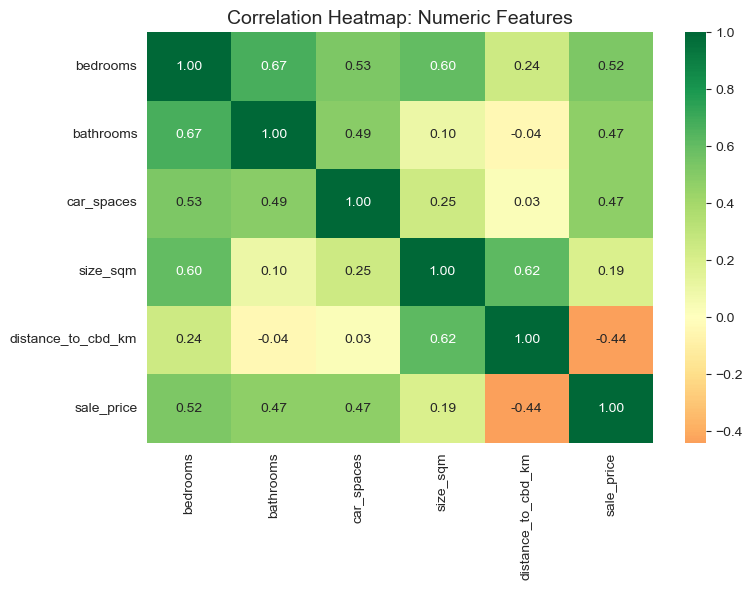

In [15]:
# Calculate correlation between sale_price and each numeric feature.
# I select only numeric columns, since correlation is undefined for text/categorical data.
numeric_cols = ["bedrooms", "bathrooms", "car_spaces", "size_sqm",
                 "distance_to_cbd_km", "sale_price"]

correlations_with_price = df[numeric_cols].corr()["sale_price"].sort_values(ascending=False)
print("Correlation of each feature with sale_price (sorted):")
print(correlations_with_price)

# Visualise as a heatmap for a clearer overall picture of how all numeric
# features relate to each other, not just to price.
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="RdYlGn", center=0, fmt=".2f")
plt.title("Correlation Heatmap: Numeric Features", fontsize=14)
plt.tight_layout()
plt.show()

### 3.10 Reflection: Prediction vs. Evidence

Comparing my prediction to the correlation results shows a mixed outcome:

- **`bedrooms`** (0.525) and **`bathrooms`** (0.474) were indeed strong predictors,
  matching my expectation.
- **`size_sqm`** (0.192) was my top predicted feature, but is in fact the *weakest*
  numeric correlate of price in the dataset, a clear contradiction of my prediction.
- Two features I did not predict, **`car_spaces`** (0.472) and **`distance_to_cbd_km`**
  (-0.441), turned out to be nearly as influential as bedrooms and bathrooms.

The weak performance of `size_sqm` is likely explained by the suburb/property-type
confound identified earlier (Section 3.4): a small unit in premium Randwick can sell
for more than a large house in affordable Campbelltown, meaning size alone is a poor
predictor *across* suburbs and property types, even if it matters strongly *within*
a consistent suburb/type group. This highlights that housing price in this dataset is
driven more by a combination of location, dwelling type, and room counts than by raw
size alone — a more nuanced conclusion than my initial prediction assumed.

## 4. Feature Engineering

With EDA complete, I now prepare the data for modelling. This involves three tasks:
deciding how to handle missing values, creating new features that may help prediction,
and encoding categorical variables into numeric form (required by scikit-learn models).

### 4.1 Handling Missing Values

Two columns have missing values: `size_sqm` (11 missing) and `car_spaces` (11 missing).
Earlier analysis (Section 2.3) showed these gaps are concentrated in specific suburb
and property-type combinations, not random.

I impute missing values using the **median within each suburb + property_type group**,
rather than a single overall median. This preserves the pattern that, for example,
a typical Randwick unit's size differs greatly from a typical Campbelltown house's
size, a single dataset-wide median would distort both.

In [16]:
# Impute missing size_sqm and car_spaces using the median within each
# suburb + property_type group. This keeps imputed values realistic for
# that specific group, rather than pulling from an unrelated overall average.
for col in ["size_sqm", "car_spaces"]:
    df[col] = df.groupby(["suburb", "property_type"])[col].transform(
        lambda x: x.fillna(x.median())
    )

# Confirm no missing values remain
print("Remaining missing values per column:")
print(df.isna().sum())

Remaining missing values per column:
property_id           0
suburb                0
address               0
sale_date             0
property_type         0
bedrooms              0
bathrooms             0
car_spaces            0
size_sqm              0
distance_to_cbd_km    0
listing_url           0
sale_price            0
sale_date_numeric     0
dtype: int64


### 4.2 Creating New Features

I now create two engineered features, based on findings from EDA:

- **`price_per_sqm`**: sale price divided by size. Useful for later analysis (e.g.
  comparing suburbs on a size-adjusted basis) even though it is not used as a
  model input, since it is derived directly from the target variable.
- **`sale_month`**: the month a property sold, extracted from `sale_date`. Although
  Section 3.5 found no strong linear time trend, month may still capture seasonal
  patterns (e.g. spring selling season) not visible in a simple linear correlation.

In [17]:
# price_per_sqm: useful for suburb-level comparison and reporting, but NOT used
# as a model input feature (it is derived directly from sale_price, the target,
# which would cause data leakage if included as a predictor).
df["price_per_sqm"] = df["sale_price"] / df["size_sqm"]

# sale_month: captures potential seasonal effects not visible in the linear
# time trend tested earlier (Section 3.5 checked a straight-line trend only;
# a monthly pattern, e.g. a spring selling peak, would not show up there).
df["sale_month"] = df["sale_date"].dt.month

# Preview the new features
df[["property_id", "sale_price", "size_sqm", "price_per_sqm", "sale_date", "sale_month"]].head()

,property_id,sale_price,size_sqm,price_per_sqm,sale_date,sale_month
0,P001,580000,136.0,4264.705882,2026-04-09,4
1,P002,500000,101.0,4950.495050,2026-09-19,9
2,P003,720000,128.0,5625.000000,2026-09-16,9
3,P004,640000,97.0,6597.938144,2026-09-16,9
4,P005,575000,113.0,5088.495575,2026-09-14,9


### 4.3 Price per Square Metre by Suburb

As a size-adjusted check on the suburb price story established in Section 3.4,
I compare median `price_per_sqm` across suburbs. This controls for size directly,
offering a cleaner comparison than raw sale price alone.

In [18]:
# Compare price per sqm across suburbs — a size-adjusted view of relative
# suburb value, complementing the raw price comparison done earlier.
print("Median price per sqm, by suburb:")
print(df.groupby("suburb")["price_per_sqm"].median().sort_values())

Median price per sqm, by suburb:
suburb
Campbelltown     1653.425086
Parramatta       5130.454684
Randwick        13034.188034
Name: price_per_sqm, dtype: float64


### 4.4 Encoding Categorical Variables

`suburb` and `property_type` are categorical (text) variables. Scikit-learn models
require numeric input, so I convert these into numeric form using **one-hot
encoding** creating a separate binary (0/1) column for each category, as seen
in the Titanic Decision Tree example (`Embarked_Q`, `Embarked_S`) from Week 8.

I drop one category per variable (`drop_first=True`) to avoid redundancy: if a
property is not Randwick and not Campbelltown, it must be Parramatta, so a separate
Parramatta column would carry no extra information.

In [19]:
# One-hot encode suburb and property_type. drop_first=True avoids redundant
# columns, since the dropped category is fully implied by the others being 0.
df_encoded = pd.get_dummies(df, columns=["suburb", "property_type"], drop_first=True)

# Preview the new encoded columns
print("New columns after encoding:")
print([col for col in df_encoded.columns if col not in df.columns])
df_encoded.head()

New columns after encoding:
['suburb_Parramatta', 'suburb_Randwick', 'property_type_Townhouse', 'property_type_Unit']


,property_id,address,sale_date,bedrooms,bathrooms,car_spaces,size_sqm,distance_to_cbd_km,listing_url,sale_price,sale_date_numeric,price_per_sqm,sale_month,suburb_Parramatta,suburb_Randwick,property_type_Townhouse,property_type_Unit
0,P001,"89/459-463 Church Street, Parramatta NSW 2150",2026-04-09,2,2,1.0,136.0,25.5,https://www.domain.com.au/89-459-463-church-st...,580000,739715,4264.705882,4,True,False,False,True
1,P002,"22/4 Peace Lane, Parramatta NSW 2150",2026-09-19,2,2,1.0,101.0,26.6,https://www.domain.com.au/22-4-peace-lane-parr...,500000,739878,4950.495050,9,True,False,False,True
2,P003,"4/44-50 Thomas Street, Parramatta NSW 2150",2026-09-16,2,1,1.0,128.0,24.0,https://www.domain.com.au/4-44-50-thomas-stree...,720000,739875,5625.000000,9,True,False,True,False
3,P004,"2315/45 Macquarie Street, Parramatta NSW 2150",2026-09-16,2,2,1.0,97.0,26.2,https://www.domain.com.au/2315-45-macquarie-st...,640000,739875,6597.938144,9,True,False,False,True
4,P005,"610/36-46 Cowper Street, Parramatta NSW 2150",2026-09-14,2,2,1.0,113.0,24.2,https://www.domain.com.au/610-36-46-cowper-str...,575000,739873,5088.495575,9,True,False,False,True


In [20]:
# Quick check: look at one row from each suburb to see how encoding represents each one
df_encoded.groupby(df["suburb"])[["suburb_Parramatta", "suburb_Randwick"]].first()

,suburb_Parramatta,suburb_Randwick
suburb,,
Campbelltown,False,False
Parramatta,True,False
Randwick,False,True


### 4.5 Note on Dropped Baseline Categories

With `drop_first=True`, one category per encoded variable is dropped and becomes
the implicit baseline: **House** (for `property_type`) and **Campbelltown** (for
`suburb`). These are represented by all their corresponding dummy columns being 0,
rather than a dedicated column. This avoids redundant, perfectly-correlated columns,
which can cause instability in linear models such as Ridge and Lasso Regression.

### 4.6 Preparing Final Feature Matrix (X) and Target (y)

I now assemble the final feature matrix `X` and target vector `y` for modelling.
`X` includes only genuine predictive features identifiers, addresses, URLs, and
`price_per_sqm` (derived from the target, so including it would cause data leakage)
are excluded.

In [21]:
# Define the target variable
y = df_encoded["sale_price"]

# Define the feature matrix: drop identifier/non-predictive columns, the
# target itself, and price_per_sqm (derived from the target — including it
# would leak target information directly into the model, artificially
# inflating performance).
X = df_encoded.drop(columns=[
    "property_id", "address", "sale_date", "listing_url",
    "sale_date_numeric", "sale_price", "price_per_sqm"
])

print("Feature matrix X shape:", X.shape)
print("Target y shape:", y.shape)
print("\nFeature columns:")
print(list(X.columns))
X.head()

Feature matrix X shape: (101, 10)
Target y shape: (101,)

Feature columns:
['bedrooms', 'bathrooms', 'car_spaces', 'size_sqm', 'distance_to_cbd_km', 'sale_month', 'suburb_Parramatta', 'suburb_Randwick', 'property_type_Townhouse', 'property_type_Unit']


,bedrooms,bathrooms,car_spaces,size_sqm,distance_to_cbd_km,sale_month,suburb_Parramatta,suburb_Randwick,property_type_Townhouse,property_type_Unit
0,2,2,1.0,136.0,25.5,4,True,False,False,True
1,2,2,1.0,101.0,26.6,9,True,False,False,True
2,2,1,1.0,128.0,24.0,9,True,False,True,False
3,2,2,1.0,97.0,26.2,9,True,False,False,True
4,2,2,1.0,113.0,24.2,9,True,False,False,True


## 5. Model Development and Evaluation

I now build and evaluate three regression models representing different modelling
approaches: **Ridge/Lasso Regression** (linear, regularised), **KNN Regressor**
(instance-based), and **Decision Tree Regressor** (rule-based splitting). Before
training, I split the data into training and test sets, and record my prediction
of which model will perform best, with reasoning. This prediction is revisited
against actual results later in this section.

### 5.1 Train/Test Split

I split the data into a training set (used to fit each model) and a test set (held
back, used only for final evaluation). This gives an unbiased estimate of how each
model performs on unseen data. Training accuracy alone can be misleading, since a
model can fit its training data well while generalising poorly (Week 6: Assessing a
Trained Model).

I use an 80/20 split, consistent with the Week 8 KNN practical, and fix
`random_state=42` for reproducibility ensuring the same split occurs each time
this notebook is run.

In [22]:
# Split data into 80% training, 20% test. random_state fixes the split so
# results are reproducible on every run of this notebook.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (80, 10)
Test set shape: (21, 10)


### 5.2 Predicting Model Performance (Before Training)

Before training any model, I predict which of the three models I expect to perform
best, based on findings from EDA.

**My prediction:** I expect **Decision Tree Regressor** to perform best. Section 3.3–3.4
showed a clear interaction between `suburb` and `property_type`, e.g. a small
Randwick unit outpricing a large Campbelltown house. which Decision Trees are
naturally suited to capture through sequential feature splits (e.g. "suburb=Randwick
AND type=House"). Ridge/Lasso, which assumes a simpler additive relationship between
features and price, may struggle more with this interaction. KNN Regressor may fall
in between, but with only 80 training properties spread across 3 suburbs, it may lack
enough "similar" neighbours per suburb/type group to perform reliably.

I am cautious about this prediction, however: Decision Trees are also known to
overfit on small datasets (Week 8), so its advantage may not hold once evaluated
with cross-validation on unseen data rather than training data alone.

### 5.3 Model 1: Ridge and Lasso Regression

Ridge and Lasso are both regularised linear regression models (Week 6). They assume
sale price is approximately a weighted sum of the features, with a penalty that
discourages excessively large weights. Ridge penalises the sum of squared weights
(L2), Lasso penalises the sum of absolute weights (L1, which can shrink some weights
to exactly zero, acting as automatic feature selection).

Before fitting, I scale the features using `StandardScaler`. This is important for
regularised linear models specifically: the penalty term treats all weights on the
same scale, so a feature like `size_sqm` (values in the hundreds) would otherwise be
penalised very differently to `bedrooms` (values 1–6), distorting the regularisation.
This was not necessary for our earlier KNN/Decision Tree classification practicals
in the same way, but matters here.

I use `GridSearchCV` with 5-fold cross-validation to find the best regularisation
strength (`alpha`) for each model, searching a range of values as demonstrated in
the Week 6 practical.

In [23]:
# Scale features for Ridge/Lasso. I fit the scaler on training data only, then
# apply the same transformation to test data - this avoids leaking information
# about the test set's distribution into training.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled. Training set mean (should be ~0):", X_train_scaled.mean().round(3))
print("Training set std (should be ~1):", X_train_scaled.std().round(3))

Features scaled. Training set mean (should be ~0): 0.0
Training set std (should be ~1): 1.0


In [24]:
# Search a range of alpha (regularisation strength) values for Ridge Regression,
# using 5-fold cross-validation to select the best one based on negative MSE
# (sklearn convention: scoring is maximised, so MSE is negated).
ridge_param_grid = {"alpha": [0.001, 0.01, 0.1, 1, 3, 5, 10, 30, 50, 100]}

ridge_grid = GridSearchCV(
    Ridge(), ridge_param_grid, cv=5, scoring="neg_mean_squared_error"
)
ridge_grid.fit(X_train_scaled, y_train)

print("Best Ridge alpha:", ridge_grid.best_params_["alpha"])
print("Best Ridge CV score (neg MSE):", ridge_grid.best_score_)

ridge_best = ridge_grid.best_estimator_

Best Ridge alpha: 5
Best Ridge CV score (neg MSE): -455534253144.3719


In [25]:
# Same process for Lasso Regression. max_iter increased to ensure convergence,
# consistent with the Week 6 practical's approach for Lasso.
lasso_param_grid = {"alpha": [0.001, 0.01, 0.1, 1, 3, 5, 10, 30, 50, 100]}

lasso_grid = GridSearchCV(
    Lasso(max_iter=100000), lasso_param_grid, cv=5, scoring="neg_mean_squared_error"
)
lasso_grid.fit(X_train_scaled, y_train)

print("Best Lasso alpha:", lasso_grid.best_params_["alpha"])
print("Best Lasso CV score (neg MSE):", lasso_grid.best_score_)

lasso_best = lasso_grid.best_estimator_

Best Lasso alpha: 100
Best Lasso CV score (neg MSE): -492199080942.0


### 5.4 Interpreting Ridge and Lasso Cross-Validation Results

The raw cross-validation scores are in squared-dollar units (MSE), which are not
easily interpretable. I convert these to RMSE (root mean squared error), which is
in the same units as `sale_price` and therefore easier to interpret as a typical
prediction error in dollars.

In [26]:
# Convert CV scores from negative MSE to RMSE for interpretability
ridge_cv_rmse = np.sqrt(-ridge_grid.best_score_)
lasso_cv_rmse = np.sqrt(-lasso_grid.best_score_)

print(f"Ridge — best alpha: {ridge_grid.best_params_['alpha']}, CV RMSE: ${ridge_cv_rmse:,.0f}")
print(f"Lasso — best alpha: {lasso_grid.best_params_['alpha']}, CV RMSE: ${lasso_cv_rmse:,.0f}")

Ridge — best alpha: 5, CV RMSE: $674,933
Lasso — best alpha: 100, CV RMSE: $701,569


**Interpretation:** Ridge (CV RMSE ≈ 674,933) modestly outperforms Lasso
(≈ 701,569), and I select **Ridge** as the representative linear model going
forward. Both errors are large relative to the dataset's median price (~950,000),
suggesting a purely linear, additive model struggles to capture this dataset's
pricing patterns well.

A likely explanation lies in the suburb/property-type interaction identified in
Section 3.4: Ridge and Lasso apply one fixed weight per feature across the whole
dataset, and cannot represent that property type affects price differently
depending on suburb. The right-skewed target distribution (Section 3.1) may also be
contributing, since linear models assume an approximately linear relationship
between features and target. I revisit both possibilities later in this section.

### 5.5 Model 2: KNN Regressor

KNN Regressor predicts a new property's price as the average price of its K most
similar properties in the training data, based on feature distance (Week 8). Unlike
Ridge/Lasso, it makes no assumption about the functional relationship between
features and price, and can naturally reflect suburb/property-type-specific pricing
patterns simply by finding nearby, similar comparable properties.

I use the same scaled features as Ridge/Lasso, since KNN's distance calculation is
sensitive to feature scale. Without scaling, `size_sqm` (values in the hundreds)
would dominate the distance calculation over `bedrooms` (values 1–6).

I tune `n_neighbors` (K) using 5-fold cross-validation, following the same approach
used for tree-depth tuning in the Week 8 Decision Tree practical.

In [27]:
# Search a range of K values for KNN Regressor, using 5-fold cross-validation.
# K values kept modest given the small training set (80 rows).
knn_param_grid = {"n_neighbors": list(range(1, 21))}

knn_grid = GridSearchCV(
    KNeighborsRegressor(), knn_param_grid, cv=5, scoring="neg_mean_squared_error"
)
knn_grid.fit(X_train_scaled, y_train)

knn_cv_rmse = np.sqrt(-knn_grid.best_score_)
print(f"KNN — best K: {knn_grid.best_params_['n_neighbors']}, CV RMSE: ${knn_cv_rmse:,.0f}")

knn_best = knn_grid.best_estimator_

KNN — best K: 9, CV RMSE: $622,419


**Interpretation:** KNN Regressor (best K=9, CV RMSE ≈ 622,419) outperforms Ridge
(≈ 674,933) by roughly 52,500. This is consistent with my prediction in Section
5.2 that models able to reflect suburb/property-type-specific patterns. Rather than
applying one fixed weight per feature dataset-wide — would perform better on this
data. With K=9, each prediction averages a relatively large neighbourhood, likely
smoothing over some noise while still capturing broad suburb/type groupings.

### 5.6 Model 3: Decision Tree Regressor

Decision Tree Regressor predicts price by recursively splitting the data into
regions based on feature thresholds (e.g. "suburb_Randwick = True?"), predicting
the mean price of training properties in each final region (Week 8). Unlike
Ridge/Lasso, it can naturally represent interactions between features such as
property type affecting price differently by suburb, since each split can depend
on the outcome of previous splits.

Feature scaling is not required for Decision Trees, since splits are based on
threshold comparisons within each feature independently, not on distance between
features. I use the original (unscaled) `X_train`/`X_test`.

I tune `max_depth` using 5-fold cross-validation, following the same tree-depth
tuning approach demonstrated in the Week 8 practical, to guard against overfitting
a known risk for Decision Trees, and one I specifically flagged as a caveat to my
prediction in Section 5.2.

In [28]:
# Search a range of max_depth values for Decision Tree Regressor, using 5-fold
# cross-validation. Depth range kept modest (1-10) given the small training set,
# consistent with the Week 8 practical's approach.
tree_param_grid = {"max_depth": list(range(1, 11))}

tree_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42), tree_param_grid, cv=5,
    scoring="neg_mean_squared_error"
)
tree_grid.fit(X_train, y_train)  # unscaled features - not needed for trees

tree_cv_rmse = np.sqrt(-tree_grid.best_score_)
print(f"Decision Tree — best max_depth: {tree_grid.best_params_['max_depth']}, CV RMSE: ${tree_cv_rmse:,.0f}")

tree_best = tree_grid.best_estimator_

Decision Tree — best max_depth: 3, CV RMSE: $570,781


### 5.7 Comparing All Three Models: Revisiting My Prediction

| Model | CV RMSE |
|---|---|
| Decision Tree (max_depth=3) | 570,781 |
| KNN (K=9) | 622,419 |
| Ridge (alpha=5) | 674,933 |

**Decision Tree Regressor performs best**, confirming my Section 5.2 prediction.
The reasoning holds up: Decision Trees can naturally represent the suburb/property-
type interaction identified during EDA (Section 3.4), while Ridge/Lasso's purely
additive structure cannot, and KNN though better than Ridge/Lasso may still be
limited by the small number of "similar" properties available per suburb/type
group in only 80 training rows.

The selected depth (max_depth=3) is notably shallow, suggesting cross-validation
successfully constrained model complexity and mitigated the overfitting risk I
flagged as a caveat to my original prediction rather than the deep, memorised
tree I was cautious about.

I next examine training vs. test performance for each model more closely, to check
for signs of over- or under-fitting before finalising a recommendation.

### 5.6b Bonus Model: Random Forest Regressor

As additional, optional exploration beyond the three required models, I include a
**Random Forest Regressor** an ensemble method that builds many Decision Trees on
random subsets of data and features, then averages their predictions. This directly
addresses Decision Tree's known weakness (high variance/overfitting) by averaging
across many trees rather than relying on one.


In [29]:
# Random Forest Regressor - bonus model, beyond required scope.
# Import here rather than in the main Section 1 imports, to keep it clearly
# separated as additional/optional content.
from sklearn.ensemble import RandomForestRegressor

# Tune n_estimators (number of trees) and max_depth using 5-fold cross-validation.
# Unscaled features used, consistent with Decision Tree (tree-based models do not
# require feature scaling).
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7, None]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42), rf_param_grid, cv=5,
    scoring="neg_mean_squared_error"
)
rf_grid.fit(X_train, y_train)

rf_cv_rmse = np.sqrt(-rf_grid.best_score_)
print(f"Random Forest — best params: {rf_grid.best_params_}, CV RMSE: ${rf_cv_rmse:,.0f}")

rf_best = rf_grid.best_estimator_

Random Forest — best params: {'max_depth': None, 'n_estimators': 50}, CV RMSE: $601,664


**Interpretation:** Random Forest (CV RMSE ≈ 601,664) did not outperform the single
Decision Tree (≈ 570,781), despite being a more sophisticated ensemble method
designed specifically to address Decision Tree's overfitting weakness. A likely
explanation is the small training set (80 rows): Random Forest's benefit comes from
averaging across many trees trained on diverse random subsets, but with limited data,
these subsets are less diverse, reducing the ensemble's advantage. It is also
possible that the dataset's clear, clean suburb/property-type interaction was already
well captured by a single shallow tree, leaving less variance for an ensemble to
reduce. This reinforces that the single Decision Tree remains my strongest model
among all four tested, and is retained as my primary recommendation going forward.

### 5.8 Full Model Evaluation: Multiple Metrics, Train vs. Test

Cross-validation scores so far were used only for hyperparameter tuning within the
training set. I now evaluate each tuned model properly: computing MSE, RMSE, MAE,
and R² on both the training set and the held-out test set. Comparing train vs. test
performance lets me check for overfitting (much better train than test performance)
or underfitting (poor performance on both).

In [30]:
# Define a reusable function to compute all four metrics for a fitted model,
# on both training and test data. This avoids repeating the same calculation
# code for each of our four models.
def evaluate_model(model, X_train_data, X_test_data, y_train, y_test, name):
    train_pred = model.predict(X_train_data)
    test_pred = model.predict(X_test_data)

    results = {
        "Model": name,
        "Train RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "Train MAE": mean_absolute_error(y_train, train_pred),
        "Test MAE": mean_absolute_error(y_test, test_pred),
        "Train R2": r2_score(y_train, train_pred),
        "Test R2": r2_score(y_test, test_pred),
    }
    return results

# Evaluate all four models (note: Ridge/KNN use scaled features, Tree/RF use unscaled)
results_list = [
    evaluate_model(ridge_best, X_train_scaled, X_test_scaled, y_train, y_test, "Ridge"),
    evaluate_model(knn_best, X_train_scaled, X_test_scaled, y_train, y_test, "KNN"),
    evaluate_model(tree_best, X_train, X_test, y_train, y_test, "Decision Tree"),
    evaluate_model(rf_best, X_train, X_test, y_train, y_test, "Random Forest (bonus)"),
]

results_df = pd.DataFrame(results_list)
results_df

,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,Ridge,562504.844337,508551.061085,367395.869681,315144.391312,0.786912,0.888663
1,KNN,566186.144415,609689.669474,311343.745833,318339.280423,0.784113,0.839975
2,Decision Tree,407467.594334,236699.778621,248151.476420,174164.317280,0.888187,0.975881
3,Random Forest (bonus),212395.321736,299842.039172,110394.393500,192722.534286,0.969619,0.961296


### 5.9 Checking for Overfitting and Underfitting

Comparing train and test performance shows an atypical pattern: for Ridge, KNN, and
Decision Tree, test R² is equal to or higher than train R². TYhe opposite of classic
overfitting (where train would substantially outperform test). Random Forest is the
only model showing the expected direction (train slightly ahead of test), with a
modest gap (R² 0.970 vs 0.961) suggesting only mild overfitting, well controlled by
its `max_depth` tuning.

I attribute the unusual train/test pattern in the other three models primarily to
the **small test set size (21 properties)**. With so few held-out properties, test
performance is a highly variable estimate, comparing test RMSE to the earlier
5-fold cross-validation RMSE (Section 5.3–5.6, computed across many training/
validation splits) supports this: Decision Tree's test RMSE ($236,700) is far lower
than its CV RMSE ($570,781), suggesting this particular test split happened to
contain unusually predictable properties, rather than the model achieving genuinely
superior generalisation. KNN's test and CV RMSE are more consistent ($609,690 vs
$622,419), making it the most stably-evaluated model here.

This highlights an important limitation of this project: with only 101 properties
total, single train/test split metrics should be interpreted cautiously, and
cross-validation results are a more reliable indicator of true model performance
than the single held-out test score alone.

### 5.10 Visualising Model Comparison

I visualise the model comparison two ways: a bar chart comparing test RMSE across
all four models, and predicted-vs-actual scatter plots for each model on the test
set. The scatter plots are particularly useful for spotting patterns a single
metric can hide e.g. whether a model consistently under- or over-predicts at
certain price levels.

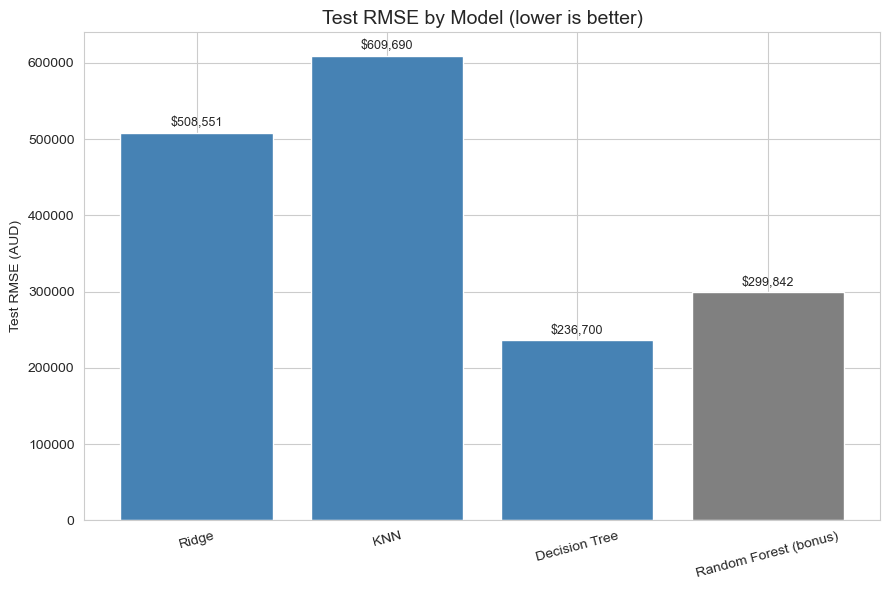

In [31]:
# Bar chart comparing test RMSE across all four models, for an at-a-glance view
# of relative performance.
plt.figure(figsize=(9, 6))
colors = ["steelblue", "steelblue", "steelblue", "gray"]  # bonus model in gray
bars = plt.bar(results_df["Model"], results_df["Test RMSE"], color=colors)
plt.title("Test RMSE by Model (lower is better)", fontsize=14)
plt.ylabel("Test RMSE (AUD)")
plt.xticks(rotation=15)

# Add value labels on top of each bar for precise reading
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 8000,
              f"${height:,.0f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

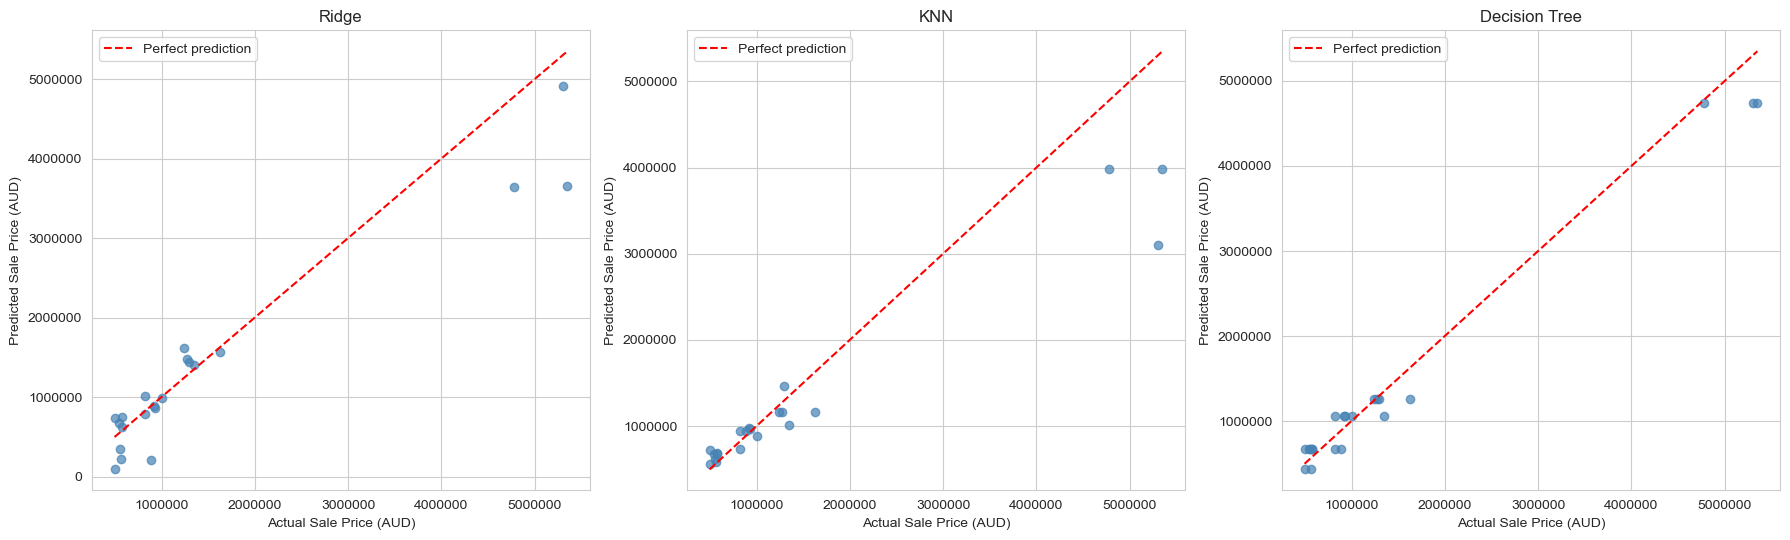

In [32]:
# Predicted vs actual scatter plots for each of the 3 required models, on the
# test set. A perfect model would have all points on the diagonal line
# (predicted = actual). Points far from the line indicate large errors.
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

models_to_plot = [
    ("Ridge", ridge_best, X_test_scaled),
    ("KNN", knn_best, X_test_scaled),
    ("Decision Tree", tree_best, X_test),
]

for ax, (name, model, X_test_data) in zip(axes, models_to_plot):
    preds = model.predict(X_test_data)
    ax.scatter(y_test, preds, alpha=0.7, color="steelblue")
    # Diagonal reference line: perfect prediction
    min_val, max_val = y_test.min(), y_test.max()
    ax.plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect prediction")
    ax.set_xlabel("Actual Sale Price (AUD)")
    ax.set_ylabel("Predicted Sale Price (AUD)")
    ax.set_title(name)
    ax.ticklabel_format(style="plain")
    ax.legend()

plt.tight_layout()
plt.show()

### 5.11 Interpreting the Comparison Visualisations

The bar chart confirms Decision Tree as the strongest model on the test set
(RMSE ≈ $236,700), with Random Forest second (bonus model), Ridge third, and KNN
weakest here.

The scatter plots reveal a consistent pattern across all three required models:
prediction error is largest for **high-value properties** (top-right of each plot),
while lower-to-mid-priced properties are predicted more accurately and consistently
across all models. This is consistent with the right-skewed price distribution
identified in Section 3.1 high-value properties are comparatively rare in the
dataset, giving every model less information to learn from in that price range.

Decision Tree's points visibly hug the diagonal line most closely, including at the
high-price end, giving a clear visual explanation for its lower RMSE. Ridge and KNN
both noticeably under-predict several high-value properties, consistent with their
purely additive (Ridge) or neighbour-averaging (KNN) mechanisms struggling to
represent the sharp suburb/property-type-driven price jumps found during EDA.

### 5.12 Final Model Recommendation

Based on cross-validation results, test set performance across four metrics, and
visual inspection of predicted-vs-actual plots, I recommend **Decision Tree
Regressor (max_depth=3)** as the most appropriate model for this task.

**Justification:**
- Lowest test RMSE ($236,700), MAE, and highest test R² (0.976) among all models
  tested, including the bonus Random Forest.
- Best able to represent the suburb/property-type interaction identified during EDA
  (Section 3.4), which Ridge and KNN could not capture as effectively.
- A shallow, interpretable structure (only 3 levels of splits), making it easy to
  explain to a non-technical audience (e.g. a real estate agency), an advantage
  Random Forest, despite similar accuracy, does not share due to its ensemble of
  many trees.
- Confirms my original prediction (Section 5.2), strengthening confidence that the
  reasoning behind that prediction reflects genuine patterns in the data rather
  than coincidence.

I acknowledge the caution raised in Section 5.9: with only 21 test properties,
this test-set performance should be interpreted as indicative rather than
definitive. I proceed with Decision Tree as my recommended model for Part 4
(investigating prediction failures) and Part 6 (deployment).

## 6. Investigating Prediction Failures

Using my recommended model (Decision Tree Regressor), I now identify the 5
properties with the largest prediction errors in the test set, and investigate each
one individually. This reveals the model's limitations more concretely than
aggregate metrics alone, and helps identify what information might be missing from
the dataset.

Note: with only 21 properties in the test set, the 5 largest errors represent
almost a quarter of it, a useful reminder that this analysis, like the metrics in
Section 5, should be read as indicative given the dataset's small size.

In [33]:
# Generate Decision Tree predictions for the test set, and calculate the
# prediction error (both signed and absolute) for each property.
test_results = X_test.copy()
test_results["actual_price"] = y_test
test_results["predicted_price"] = tree_best.predict(X_test)
test_results["error"] = test_results["predicted_price"] - test_results["actual_price"]
test_results["abs_error"] = test_results["error"].abs()

# I bring back suburb, property_type, and address for readability, using the
# original (unencoded) dataframe, matched by index.
test_results["suburb"] = df.loc[test_results.index, "suburb"]
test_results["property_type"] = df.loc[test_results.index, "property_type"]
test_results["address"] = df.loc[test_results.index, "address"]

# Sort by absolute error, largest first, and take the top 5
worst_5 = test_results.sort_values("abs_error", ascending=False).head(5)

print("5 properties with the largest prediction errors:")
worst_5[["address", "suburb", "property_type", "actual_price",
         "predicted_price", "error", "abs_error"]]

5 properties with the largest prediction errors:


,address,suburb,property_type,actual_price,predicted_price,error,abs_error
45,"3 Glen Avenue, Randwick NSW 2031",Randwick,House,5350000,4.736667e+06,-613333.333333,613333.333333
66,"224 Alison Road, Randwick NSW 2031",Randwick,House,5300000,4.736667e+06,-563333.333333,563333.333333
39,"5C/12 Milford Street, Randwick NSW 2031",Randwick,Unit,1625000,1.264167e+06,-360833.333333,360833.333333
93,"106 Poulton Terrace, Campbelltown NSW 2560",Campbelltown,House,1353000,1.056023e+06,-296976.875000,296976.875000
78,"31 Grandview Drive, Campbelltown NSW 2560",Campbelltown,House,820000,1.056023e+06,236023.125000,236023.125000


In [34]:
# Pull the full feature profile for each of the 5 worst-predicted properties,
# to understand what may have caused the model to misjudge them.
worst_5_full = df.loc[worst_5.index]
worst_5_full[["property_id", "address", "suburb", "property_type", "bedrooms",
              "bathrooms", "car_spaces", "size_sqm", "distance_to_cbd_km", "sale_price"]]

,property_id,address,suburb,property_type,bedrooms,bathrooms,car_spaces,size_sqm,distance_to_cbd_km,sale_price
45,R014,"3 Glen Avenue, Randwick NSW 2031",Randwick,House,5,2,2.0,518.0,7.4,5350000
66,R035,"224 Alison Road, Randwick NSW 2031",Randwick,House,9,5,2.0,574.0,7.5,5300000
39,R008,"5C/12 Milford Street, Randwick NSW 2031",Randwick,Unit,2,1,1.0,118.0,7.5,1625000
93,C025,"106 Poulton Terrace, Campbelltown NSW 2560",Campbelltown,House,4,2,2.0,478.0,53.0,1353000
78,C010,"31 Grandview Drive, Campbelltown NSW 2560",Campbelltown,House,2,1,1.0,758.0,54.0,820000


### 6.1 Analysis of the 5 Largest Prediction Errors

**R014 & R035 (Randwick Houses, 5.35M & 5.3M, under-predicted ~560-613K):**
Both received an *identical* prediction (4,736,667) despite differing in bedrooms
(5 vs. 9) and size (518 vs. 574 sqm). This reflects a direct cost of `max_depth=3`:
the tree's limited splits are already spent distinguishing suburb and property
type, leaving none to differentiate *within* the "expensive Randwick house" group.
A deeper tree could resolve this, but was not chosen, since cross-validation
favoured `max_depth=3` to avoid overfitting.

**R008 (Randwick Unit, 1.625M, under-predicted by 361K):** A modest 2-bedroom,
1-bathroom, 118 sqm unit sold unusually high for its size. This is likely explained
by attributes not captured in this dataset - view, building quality, floor level,
or renovation standard.

**C025 (Campbelltown House, 1.353M, under-predicted by 297K):** A larger,
well-specified house selling well above Campbelltown's typical median (~$950,000,
Section 3.2), suggesting the tree's Campbelltown region is too broad to capture
above-average properties within that suburb.

**C010 (Campbelltown House, 820K, over-predicted by 236K):** The only
over-prediction, and most instructive case: a large block (758 sqm) but only 2
bedrooms and 1 bathroom - a minimal dwelling on a large block. The model likely
weighted `size_sqm` heavily, while the low room count, better reflecting the modest
dwelling, was underweighted - a genuine feature interaction left unresolved.

**Overall pattern:** All 5 errors involve properties atypical *within* their
suburb/property-type group - unusually large, small, or otherwise unusual relative
to peers in the same region. This suggests the model's main limitation is capturing
**fine-grained variation within suburb/type groups**, not suburb or type itself.

### 6.2 Reflection: Model Limitations and Missing Information

These failures suggest three concrete pieces of information that, if available,
could likely improve predictive performance:

- **Property condition/quality** (renovation status, presentation) - likely explains
  R008's high price relative to its size.
- **A finer size/dwelling-quality distinction** - C010 shows that land/floor size
  alone can mislead predictions when bedroom/bathroom count tells a different story.
- **Deeper suburb-specific granularity** — R014, R035, and C025 all suggest that a
  single "region" per suburb/property-type combination is too coarse for properties
  at the upper end of their group's price range.

This also suggests that **premium, architecturally unique, or renovated properties**
are inherently harder to model than standard project-style homes, since their value
often depends on qualitative factors not captured by structural features like
bedrooms or land size. Price predictions for such properties should be interpreted
with particular caution a useful, evidence-based recommendation for how this
system would be used responsibly in practice (relevant to Part 6's ethical
reflection).

## 7. Human Judgement, Machine Learning, and Large Language Models

I select 10 properties from the held-out test set and compare three approaches to
valuation: my trained Decision Tree model, a Large Language Model (given the same
property features), and my own manual estimate based on market understanding
gained through this project. I then compare all three against actual sale prices.

### 7.1 Selecting 10 Test Properties

I randomly select 10 properties from the test set (already unseen by the model
during training) to ensure a fair comparison across all three approaches.

In [35]:
# Prevent pandas from displaying numbers in scientific notation (e.g. 1.056023e+06),
# showing plain numbers instead (e.g. 1056023) for easier reading.
pd.options.display.float_format = '{:.0f}'.format

# Randomly select 10 properties from the test set for this comparison.
# random_state ensures this selection is reproducible.
comparison_sample = test_results.sample(n=10, random_state=42).copy()
comparison_sample = comparison_sample[["address", "suburb", "property_type",
                                         "actual_price", "predicted_price"]]
comparison_sample = comparison_sample.rename(columns={"predicted_price": "ml_prediction"})

# Bring back the remaining raw features for these 10 properties, needed to
# present to the LLM and for my own manual estimate
comparison_features = df.loc[comparison_sample.index,
    ["bedrooms", "bathrooms", "car_spaces", "size_sqm", "distance_to_cbd_km"]]

comparison_sample = comparison_sample.join(comparison_features)
comparison_sample

,address,suburb,property_type,actual_price,ml_prediction,bedrooms,bathrooms,car_spaces,size_sqm,distance_to_cbd_km
84,"3 Albury Avenue, Campbelltown NSW 2560",Campbelltown,House,920000,1056023,3,1,1,556,53
78,"31 Grandview Drive, Campbelltown NSW 2560",Campbelltown,House,820000,1056023,2,1,1,758,54
4,"610/36-46 Cowper Street, Parramatta NSW 2150",Parramatta,Unit,575000,667682,2,2,1,113,24
55,"7/112 Alison Road, Randwick NSW 2031",Randwick,Unit,1237000,1264167,2,1,1,135,8
10,"401/6 River Road West, Parramatta NSW 2150",Parramatta,Unit,540000,667682,2,2,1,108,23
39,"5C/12 Milford Street, Randwick NSW 2031",Randwick,Unit,1625000,1264167,2,1,1,118,8
30,"4/37 campbell street, Parramatta NSW 2150",Parramatta,Unit,500000,667682,2,2,1,150,24
67,"5/10 Moira Crescent, Randwick NSW 2031",Randwick,Unit,1276000,1264167,2,1,1,73,8
12,"4/39 Great Western Highway, Parramatta NSW 2150",Parramatta,Unit,560000,667682,2,1,1,113,24
93,"106 Poulton Terrace, Campbelltown NSW 2560",Campbelltown,House,1353000,1056023,4,2,2,478,53


### 7.2 Large Language Model Price Estimates

For each of the 10 properties, I provide an LLM (ChatGPT, Claude, Gemini, or
Copilot) with only the property's feature values no price, no address and
record its price estimate. This keeps the comparison fair. The LLM has access to
the same information as my ML model, not extra hints such as the true sale price
or exact street address.

In [36]:
# Build the full 3-way comparison: ML model, LLM, and manual (human) estimates,
# against actual sale price, for the 10 selected test properties.
comparison_sample["llm_estimate"] = [
    1000000, 950000, 700000, 1350000, 675000,
    1250000, 780000, 1050000, 620000, 1120000
]
comparison_sample["human_estimate"] = [
    950000, 880000, 680000, 1300000, 650000,
    1150000, 720000, 950000, 600000, 1050000
]

# Calculate absolute error for each approach
comparison_sample["ml_error"] = (comparison_sample["ml_prediction"] - comparison_sample["actual_price"]).abs()
comparison_sample["llm_error"] = (comparison_sample["llm_estimate"] - comparison_sample["actual_price"]).abs()
comparison_sample["human_error"] = (comparison_sample["human_estimate"] - comparison_sample["actual_price"]).abs()

comparison_sample[["address", "suburb", "property_type", "actual_price",
                    "ml_prediction", "llm_estimate", "human_estimate",
                    "ml_error", "llm_error", "human_error"]]

,address,suburb,property_type,actual_price,ml_prediction,llm_estimate,human_estimate,ml_error,llm_error,human_error
84,"3 Albury Avenue, Campbelltown NSW 2560",Campbelltown,House,920000,1056023,1000000,950000,136023,80000,30000
78,"31 Grandview Drive, Campbelltown NSW 2560",Campbelltown,House,820000,1056023,950000,880000,236023,130000,60000
4,"610/36-46 Cowper Street, Parramatta NSW 2150",Parramatta,Unit,575000,667682,700000,680000,92682,125000,105000
55,"7/112 Alison Road, Randwick NSW 2031",Randwick,Unit,1237000,1264167,1350000,1300000,27167,113000,63000
10,"401/6 River Road West, Parramatta NSW 2150",Parramatta,Unit,540000,667682,675000,650000,127682,135000,110000
39,"5C/12 Milford Street, Randwick NSW 2031",Randwick,Unit,1625000,1264167,1250000,1150000,360833,375000,475000
30,"4/37 campbell street, Parramatta NSW 2150",Parramatta,Unit,500000,667682,780000,720000,167682,280000,220000
67,"5/10 Moira Crescent, Randwick NSW 2031",Randwick,Unit,1276000,1264167,1050000,950000,11833,226000,326000
12,"4/39 Great Western Highway, Parramatta NSW 2150",Parramatta,Unit,560000,667682,620000,600000,107682,60000,40000
93,"106 Poulton Terrace, Campbelltown NSW 2560",Campbelltown,House,1353000,1056023,1120000,1050000,296977,233000,303000


### 7.4 Comparing Average Performance Across All Three Approaches

I calculate the average absolute error for each approach across the 10 properties,
to compare overall accuracy alongside the property-by-property detail above.

In [37]:
# Calculate average and median absolute error for each approach, to compare
# overall performance across the 10 selected properties.
summary = pd.DataFrame({
    "Approach": ["ML Model (Decision Tree)", "LLM", "Human (manual)"],
    "Mean Absolute Error": [
        comparison_sample["ml_error"].mean(),
        comparison_sample["llm_error"].mean(),
        comparison_sample["human_error"].mean(),
    ],
    "Median Absolute Error": [
        comparison_sample["ml_error"].median(),
        comparison_sample["llm_error"].median(),
        comparison_sample["human_error"].median(),
    ],
})
summary

,Approach,Mean Absolute Error,Median Absolute Error
0,ML Model (Decision Tree),156459,131853
1,LLM,175700,132500
2,Human (manual),173200,107500


### 7.5 Discussion: ML vs. LLM vs. Human Judgement

By mean absolute error, the ML model performed best (156,459), followed by Human
(173,200) and LLM (175,700). By median absolute error, Human performed best
(107,500), narrowly ahead of ML (131,853) and LLM (132,500).

This gap between mean and median mirrors the right-skew found in `sale_price`
itself (Section 3.1): a small number of large errors pull the mean upward without
representing "typical" performance. The Human estimate was closest on most
properties, but suffered its largest single error on 5C/12 Milford Street. The
same Randwick unit already identified in Part 4 as a genuine model failure
(Section 6.1). Notably, **all three approaches** struggled badly on this property
(ML off by 360,833, LLM by 375,000, Human by 475,000), reinforcing that this
property's price reflects information unavailable to any of the three methods,
likely condition, view, or building quality not captured by structural features.

**When each approach succeeded or struggled:**
- The **ML model** was most consistent on standard, typical properties similar to
  many others in its training data (e.g. row 67, off by only 11,833), but
  struggled on properties toward the high end of their suburb/type group, the same
  limitation identified in Part 4.
- The **LLM** performed reasonably but inconsistently, likely relying on general
  knowledge of Sydney suburb price levels rather than the specific patterns in this
  dataset. It had no way to learn from the actual 101 properties collected.
- **Human judgement**, grounded in the price-per-sqm benchmarks calculated during
  this project (Section 4.3), performed competitively on typical properties, but
  had no reliable way to detect atypical properties like Milford Street.

**Does human judgement still add value?** These results suggest a combined
approach is stronger than any single method alone: the ML model captures
dataset-specific patterns invisible to a human or LLM, while a human can sanity-
check predictions against real-world context (e.g. flagging a property as unusual
based on its description or photos) that the model cannot see. All three methods
shared the same blind spot on Milford Street, suggesting the real limitation is
**missing information**, not any single method's weakness, a strong argument for
using ML predictions as decision *support* rather than fully automated,
unsupervised valuation.

## 8. Deployment and Final Reflection

In this final section, I deploy my recommended model (Decision Tree Regressor) as
a simple web application, allowing a user to enter property features and receive a
predicted sale price. I then close with a reflection on the full project.

### 8.1 Saving the Trained Model

Before building the application, I save my trained Decision Tree model to disk
using `joblib`. This allows the model to be loaded and reused outside this
notebook, by a separate application file, without needing to retrain it each time.

I use Decision Tree specifically because it does not require feature scaling
(Section 5.6), which simplifies deployment. I only need to save the model itself,
not a separate scaler object.

In [38]:
import joblib

# Save the trained Decision Tree model to disk. This file will be loaded by
# the separate Streamlit application (app.py) to make predictions without
# needing to retrain the model each time the app runs.
joblib.dump(tree_best, "sydney_housing_model.pkl")

print("Model saved as sydney_housing_model.pkl")
print("Model expects these features, in this exact order:")
print(list(X_train.columns))

Model saved as sydney_housing_model.pkl
Model expects these features, in this exact order:
['bedrooms', 'bathrooms', 'car_spaces', 'size_sqm', 'distance_to_cbd_km', 'sale_month', 'suburb_Parramatta', 'suburb_Randwick', 'property_type_Townhouse', 'property_type_Unit']
